den store fil 

## vi har nu:

# Preprocessing
import af alle predictors
averaging til én værdi per år
kombination baseret på valgåret

# modelling
en simpel OLS model - med flere sæt predictors

# evaluation
En LOOCV



### vi mangler:
# Preprocessing
(en mere sofistikeret vægtning når flere  målinger pr år)
interpolation af manglende år
kombination baseret på alle år, evt baseret på vægte estimeret ved regression (eller en model der kan have en højere resolution i x end i y)

# Modelling
En analyse af colinearity/kombination af variable for at komme af med den
en ols model rafineret efter chapt 6
en form for bayesian regression eller noget?
En form for tree based method - BART?
lasso?  - måske skal vi lave en lasso for alle predictors, og en for kun økonomiske? sådan at vi kan lave økonomiske og wellbeing sammenligningen
lasso med crossvalidation for at ifnde maximum - vi må hellere få lavet den rette
PCA på ecoonomics?

vi har high dimensions

# Evaluation
En leave future out validation (der er mange valg her fx ift om man kun skal evaluere på nogle få valg og om man skal fjerne det seenste)

en analyse af hvilke predictors der er vigtige og hvad det  btyder

In [335]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import sklearn

In [336]:
import os

In [337]:
os.getcwd()

'c:\\Users\\carle\\Documents\\Cognitive_Science\\MASTER\\Data science\\Data science exam\\data_science'

In [338]:
gini = pd.read_csv('data/gini.csv', index_col=0, skiprows=3)
gdp = pd.read_csv('data/gdp.csv', index_col=0, skiprows=3)
inflation = pd.read_csv('data/inflation.csv', index_col=0, skiprows=3)
unemployment = pd.read_csv('data/unemployment.csv', index_col=0, skiprows=3)

In [339]:
gdp.head()

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.485815,3.048518,0.951664,-23.466273,15.675519,11.038520,7.657640,6.181751,NaN,NaN
Africa Eastern and Southern,AFE,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,-2.182395,5.075379,2.795642,1.790384,2.225029,1.922442,...,0.000238,-0.064991,-0.709407,-5.405934,1.844404,1.068005,-0.604582,0.253854,NaN,NaN
Afghanistan,AFG,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.195570,-1.713743,0.856295,-5.382515,-22.584482,-7.576669,0.106093,NaN,NaN,NaN
Africa Western and Central,AFW,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,-0.251185,1.538542,4.740660,3.086962,1.823450,-3.703529,...,-0.355283,0.330202,0.792058,-6.003416,0.154018,2.064401,1.218110,2.107058,NaN,NaN
Angola,AGO,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.622865,-3.968525,-3.529000,-7.127615,-1.094341,0.991407,-1.808703,1.292933,NaN,NaN


In [340]:
gini, gdp, inflation, unemployment = [
    df.loc[['United States']]
    for df in [gini, gdp, inflation, unemployment]
]

In [341]:
gini, gdp, inflation, unemployment = [
    df.drop(columns=["Country Code", "Indicator Name", "Indicator Code", "Unnamed: 70"])
    for df in [gini, gdp, inflation, unemployment]
]

In [342]:
gini, gdp, inflation, unemployment = [
    df.melt(var_name="year", value_name=name)
    for df, name in zip(
        [gini, gdp, inflation, unemployment],
        ["gini", "gdp", "inflation", "unemployment"]
    )
]

In [343]:
gini['year'], gdp['year'], inflation['year'], unemployment['year'] = [
    df["year"].astype(int)
    for df in [gini, gdp, inflation, unemployment]
]

In [344]:
gdp

,year,gdp
0,1960,NaN
1,1961,0.618121
2,1962,4.480669
3,1963,2.908272
4,1964,4.340549
...,...,...
61,2021,5.888341
62,2022,1.923862
63,2023,2.035600
64,2024,1.794192


In [345]:
income = pd.read_csv('data/Real wage.csv')
satisfaction = pd.read_csv('data/satisfaction.csv')

In [346]:
income['median_real_wage'] = income['LES1252881600Q']

In [347]:
income['year'] = income['observation_date'].str[:4]
income.head()

,observation_date,LES1252881600Q,median_real_wage,year
0,1979-01-01,335.0,335.0,1979
1,1979-04-01,335.0,335.0,1979
2,1979-07-01,330.0,330.0,1979
3,1979-10-01,326.0,326.0,1979
4,1980-01-01,321.0,321.0,1980


In [348]:
satisfaction['year'] = satisfaction['In general, are you satisfied or dissatisfied with the way things are going in [your personal life/the United States] at this time? <br><b>% Satisfied</b>'].str[-4:]

In [349]:
yearly_wage = income.groupby('year')['median_real_wage'].mean()
yearly_pers = satisfaction.groupby('year')['Personal life'].mean()
yearly_us = satisfaction.groupby('year')['United States'].mean()

In [350]:
yearly_wage = pd.DataFrame(index= yearly_wage.index, data=yearly_wage.values, columns=['wage'])
yearly_pers = pd.DataFrame(index= yearly_pers.index, data=yearly_pers.values, columns=['pers'])
yearly_us = pd.DataFrame(index= yearly_us.index, data=yearly_us.values, columns=['us'])

In [351]:
yearly_wage.reset_index(inplace=True)
yearly_pers.reset_index(inplace=True)
yearly_us.reset_index(inplace=True)


In [352]:
yearly_pers.head()

,year,pers
0,1979,76.333333
1,1981,81.000000
2,1982,75.500000
3,1983,77.000000
4,1984,79.000000


In [353]:
yearly_pers.interpolate

<bound method NDFrame.interpolate of     year       pers
0   1979  76.333333
1   1981  81.000000
2   1982  75.500000
3   1983  77.000000
4   1984  79.000000
5   1985  82.000000
6   1986  84.000000
7   1987  83.000000
8   1988  86.500000
9   1990  84.000000
10  1991  83.125000
11  1992  78.000000
12  1993  82.000000
13  1996  86.000000
14  1998  86.000000
15  2000  87.000000
16  2001  84.500000
17  2002  84.000000
18  2003  86.500000
19  2004  84.000000
20  2005  85.000000
21  2006  84.000000
22  2007  84.000000
23  2008  80.000000
24  2011  78.000000
25  2013  79.000000
26  2015  85.000000
27  2016  85.000000
28  2017  87.000000
29  2019  86.000000
30  2020  90.000000
31  2021  82.000000
32  2022  85.000000
33  2023  83.000000
34  2024  78.000000
35  2025  81.000000>

In [354]:
election_results = pd.read_csv('data/election_results.csv')

In [355]:
election_results.head()

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain


In [356]:
gini.head(10)

,year,gini
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,36.7
4,1964,37.4
5,1965,36.8
6,1966,37.1
7,1967,36.9
8,1968,36.3
9,1969,36.0


In [381]:
# Define weights for each year of the term (most recent year = highest weight)

def weighted_term_mean(df, value_column, election_years, weights):
    results = []
    for ey in election_years:
        term_years = list(range(ey - 3, ey + 1))  # 4 years leading up to election
        term_data = df[df['year'].isin(term_years)].sort_values('year')
        
        if len(term_data) >= 2:
            w = weights[-len(term_data):]
            w_mean = np.average(term_data[f'{value_column}'].values, weights=w)
        else:
            w_mean = np.nan  # not enough data
            
        results.append({'year': ey, f'{value_column}': w_mean})
    
    return pd.DataFrame(results)

weights = [0.1, 0.2, 0.3, 0.4]
gini_weighted = weighted_term_mean(gini, 'gini', election_results['year'].tolist(), weights)

prediction_data = pd.merge(election_results, gini_weighted, how='left', on='year')


In [382]:
gini_weighted

,year,gini
0,2024,41.57
1,2020,41.07
2,2016,41.40
3,2012,40.97
4,2008,41.24
5,2004,40.58
6,2000,40.09
7,1996,40.13
8,1992,38.24
9,1988,37.52


In [383]:
gdp_weighted = weighted_term_mean(gdp, 'gdp', election_results['year'].tolist(), weights)

prediction_data = pd.merge(prediction_data, gdp_weighted, how = 'left', on=['year'])

In [384]:
unemployment_weighted = weighted_term_mean(unemployment, 'unemployment', election_results['year'].tolist(), weights)
prediction_data = pd.merge(prediction_data, unemployment_weighted, how = 'left', on=['year'])

In [385]:
inflation_weighted = weighted_term_mean(inflation, 'inflation', election_results['year'].tolist(), weights)
prediction_data = pd.merge(prediction_data, inflation, how = 'left', on=['year'])

In [386]:
yearly_wage['year'] = yearly_wage['year'].astype(int)
yearly_pers['year'] = yearly_pers['year'].astype(int)
yearly_us['year'] = yearly_us['year'].astype(int)

In [387]:
yearly_wage

,year,wage
0,1979,331.50
1,1980,317.50
2,1981,311.50
3,1982,312.50
4,1983,314.00
5,1984,313.50
6,1985,319.25
7,1986,327.00
8,1987,328.50
9,1988,325.75


In [388]:
wage_weighted = weighted_term_mean(yearly_wage, 'wage', election_results['year'].tolist(), weights)
pers_weighted = weighted_term_mean(yearly_pers, 'pers', election_results['year'].tolist(), weights)
us_weighted = weighted_term_mean(yearly_us, 'us', election_results['year'].tolist(), weights)

In [389]:
us_weighted

,year,us
0,2024,19.400000
1,2020,32.666667
2,2016,26.000000
3,2012,NaN
4,2008,21.600000
5,2004,49.200000
6,2000,56.857143
7,1996,38.000000
8,1992,34.623457
9,1988,50.400000


In [390]:
prediction_data = pd.merge(prediction_data, wage_weighted, how = 'left', on=['year'])
prediction_data = pd.merge(prediction_data, pers_weighted, how = 'left', on=['year'])
prediction_data = pd.merge(prediction_data, us_weighted, how = 'left', on=['year'])

In [391]:
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,2.949525,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.233584,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.261583,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.069337,337.600,NaN,NaN
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.839100,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.677237,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,3.376857,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.931204,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,3.028820,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,4.077741,326.175,84.500000,50.400000


In [392]:
#linear interpolation
prediction_data['pers'] = prediction_data['pers'].interpolate()
prediction_data['us'] = prediction_data['us'].interpolate()

In [393]:
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,2.949525,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.233584,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.261583,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.069337,337.600,83.083333,23.800000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.839100,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.677237,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,3.376857,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.931204,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,3.028820,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,4.077741,326.175,84.500000,50.400000


In [394]:
prediction_data = prediction_data.dropna()

In [395]:
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,2.949525,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.233584,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.261583,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.069337,337.600,83.083333,23.800000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.839100,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.677237,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,3.376857,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.931204,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,3.028820,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,4.077741,326.175,84.500000,50.400000


In [396]:
from sklearn.preprocessing import StandardScaler
scaled_prediction_data = prediction_data.copy()

cols_to_scale = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us']  # standardizing predictors that are not categroical and the outcome

sc = StandardScaler()
scaled_prediction_data[cols_to_scale] = sc.fit_transform(scaled_prediction_data[cols_to_scale])

scaled_prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,0.978299,0.556138,-1.484590,-0.266619,1.935012,-0.563802,-1.428745
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,0.735746,-1.541418,-0.362971,-0.821145,1.850341,1.708498,-0.271093
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,0.895831,-0.235034,-0.387724,-0.812097,0.450359,0.238851,-0.852828
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,0.687235,-0.928747,1.938978,-0.551062,0.235763,0.041014,-1.044800
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,0.818214,-1.182503,-0.651312,0.020857,0.051824,-0.156823,-1.236773
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,0.498043,0.126423,-0.291206,-0.354612,0.221165,0.623220,1.171610
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,0.260341,1.492255,-1.270867,-0.128522,-0.308755,1.223999,1.839774
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,0.279745,0.414211,-0.183346,-0.272540,-1.132102,0.448801,0.194295
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,-0.637107,-0.944981,0.459251,-0.240994,-1.098526,-0.651416,-0.100343
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,-0.986384,1.145824,0.095436,0.097976,-0.431381,0.521476,1.276322


In [397]:
scaled_prediction_data.dtypes

year                                                        int64
prospective conscutive term for incumbent party             int64
prospective 1st/2nd term for incumbent party candidate      int64
incumbent party                                            object
popular vote for incumbent party                          float64
popular vote for non-incumbent party                      float64
winner party                                               object
winner president                                           object
loser                                                      object
gini                                                      float64
gdp                                                       float64
unemployment                                              float64
inflation                                                 float64
wage                                                      float64
pers                                                      float64
us        

In [398]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(categories=[['1', '2', '3', '4']])  # specify order
scaled_prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(scaled_prediction_data[['prospective conscutive term for incumbent party']])

enc = OrdinalEncoder(categories=[['1', '2']])  # specify order
scaled_prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(scaled_prediction_data[['prospective 1st/2nd term for incumbent party candidate']]) #,aybe we should introduce a varibale reflecting the presence of populist candidates, or something regaridn the non-incumbent candidates

In [399]:
scaled_prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,0.0,0.0,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,0.978299,0.556138,-1.484590,-0.266619,1.935012,-0.563802,-1.428745
1,2020,0.0,0.0,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,0.735746,-1.541418,-0.362971,-0.821145,1.850341,1.708498,-0.271093
2,2016,2.0,0.0,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,0.895831,-0.235034,-0.387724,-0.812097,0.450359,0.238851,-0.852828
3,2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,0.687235,-0.928747,1.938978,-0.551062,0.235763,0.041014,-1.044800
4,2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,0.818214,-1.182503,-0.651312,0.020857,0.051824,-0.156823,-1.236773
5,2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,0.498043,0.126423,-0.291206,-0.354612,0.221165,0.623220,1.171610
6,2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,0.260341,1.492255,-1.270867,-0.128522,-0.308755,1.223999,1.839774
7,1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,0.279745,0.414211,-0.183346,-0.272540,-1.132102,0.448801,0.194295
8,1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,-0.637107,-0.944981,0.459251,-0.240994,-1.098526,-0.651416,-0.100343
9,1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,-0.986384,1.145824,0.095436,0.097976,-0.431381,0.521476,1.276322


In [400]:
scaled_prediction_data= scaled_prediction_data.set_index('year')

In [401]:
scaled_prediction_data = scaled_prediction_data.sort_index()

In [402]:
scaled_prediction_data

,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
year,,,,,,,,,,,,,,,
1980,1.0,1.0,Democratic,41.00,50.70,Republican,Ronald Reagan,Jimmy Carter,-2.291322,-0.393346,0.330846,3.158784,-0.587584,-1.716910,0.226290
1984,1.0,1.0,Republican,58.80,40.60,Republican,Ronald Reagan,Walter Mondale,-1.238640,1.491179,1.807505,0.169975,-1.186116,-1.716910,0.226290
1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,-0.986384,1.145824,0.095436,0.097976,-0.431381,0.521476,1.276322
1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,-0.637107,-0.944981,0.459251,-0.240994,-1.098526,-0.651416,-0.100343
1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,0.279745,0.414211,-0.183346,-0.272540,-1.132102,0.448801,0.194295
2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,0.260341,1.492255,-1.270867,-0.128522,-0.308755,1.223999,1.839774
2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,0.498043,0.126423,-0.291206,-0.354612,0.221165,0.623220,1.171610
2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,0.818214,-1.182503,-0.651312,0.020857,0.051824,-0.156823,-1.236773
2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,0.687235,-0.928747,1.938978,-0.551062,0.235763,0.041014,-1.044800


SÅ ER DATAEN FÆRDIG

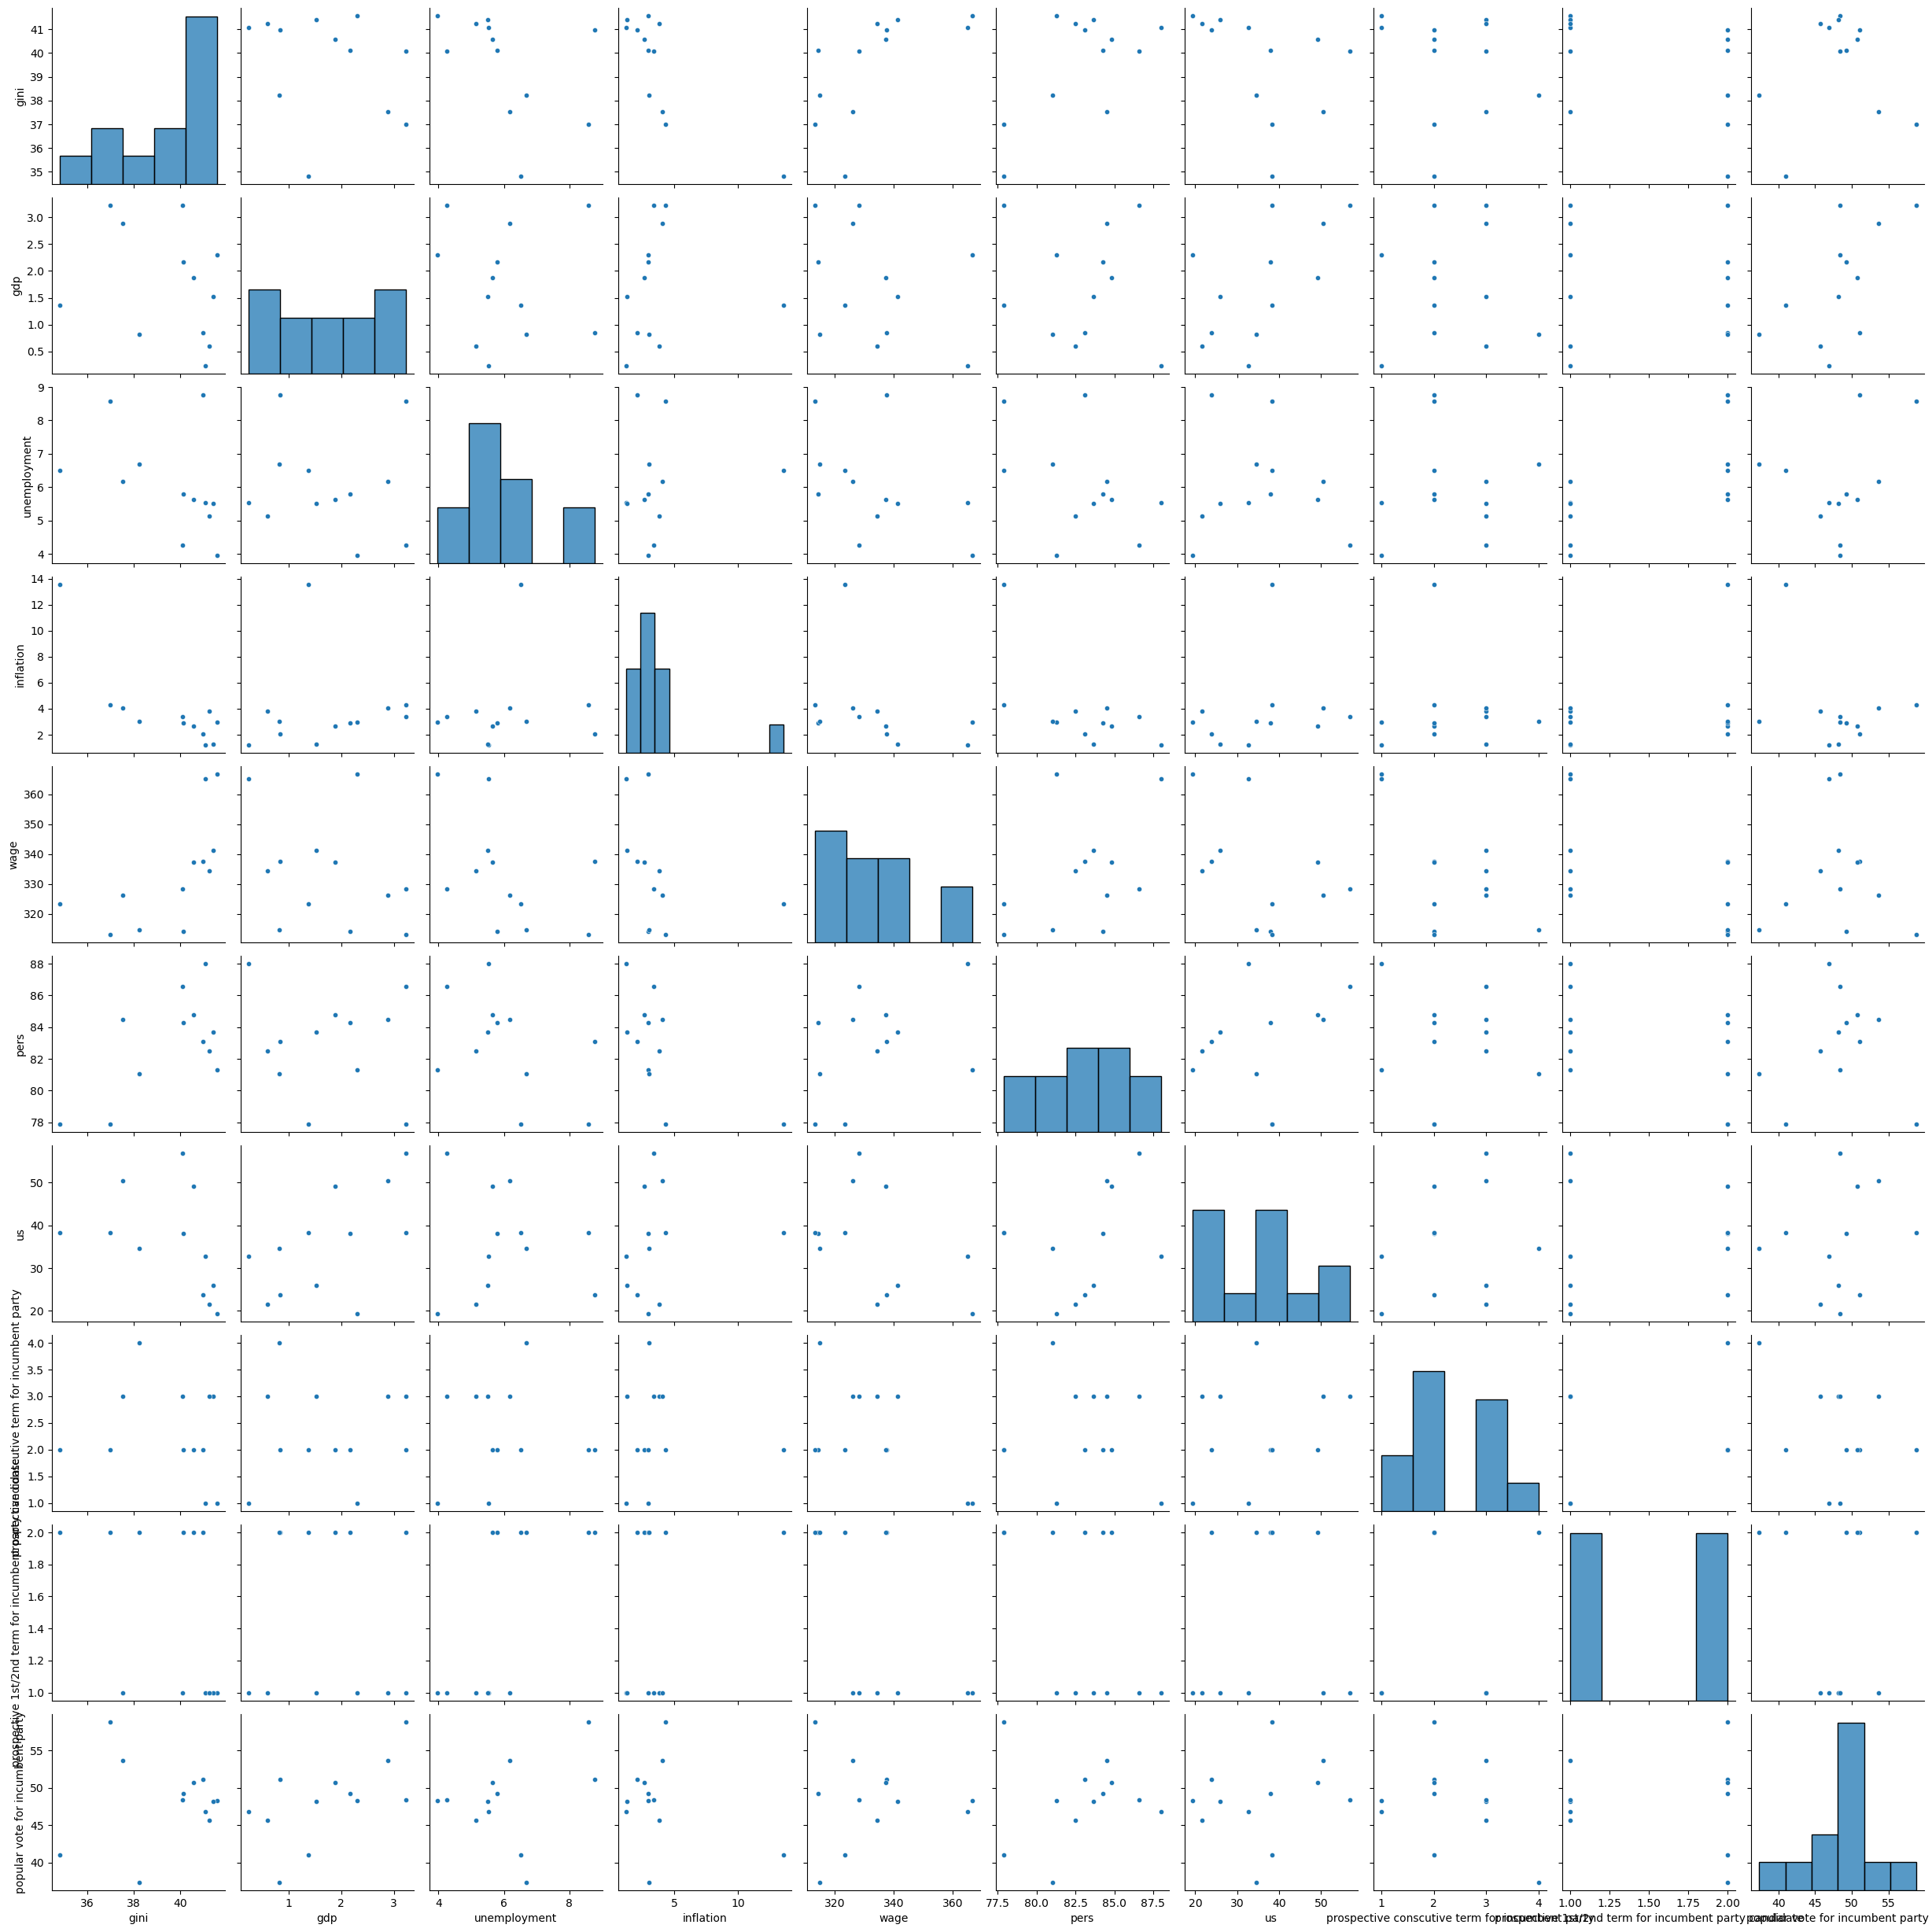

In [407]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate', 'popular vote for incumbent party']

sns.pairplot(prediction_data[cols], plot_kws={'alpha': 1, 's': 20})
plt.show()

In [403]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF 
from statsmodels.stats.anova import anova_lm

In [404]:
X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

In [405]:
X = scaled_prediction_data[['gini', 'gdp', 'pers']]

In [406]:
X = scaled_prediction_data[['gini', 'gdp', 'pers', 'us']]

In [204]:
X = scaled_prediction_data[['gini', 'unemployment', 'inflation', 'wage', 'pers', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

In [205]:
X = scaled_prediction_data[['gdp', 'inflation', 'unemployment', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

In [408]:
vals = [VIF(X, i)  
    for i in range(1, X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns[1:]) 
vif

,vif
gdp,2.438433
pers,6.167238
us,6.326986


problems from the book:
1. Non-linearity of the response-predictor relationships. 
2. Correlation of error terms. 
3. Non-constant variance of error terms. 
4. Outliers. 
5. High-leverage points. 
6. Collinearity. - decreases accuracy -indentifiability problems
and thus rreduces power of the test, increases p values

In [207]:
import statsmodels.api as sm

In [409]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
summarize ,
poly)

In [ ]:
results.summary()

c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                   
============================================================================================
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.681
Model:                                          OLS   Adj. R-squared:                  0.282
Method:                               Least Squares   F-statistic:                     1.707
Date:                              Mon, 18 May 2026   Prob (F-statistic):              0.312
Time:                                      09:24:51   Log-Likelihood:                -24.972
No. Observations:                                10   AIC:                             61.94
Df Residuals:                                     4   BIC:                             63.76
Df Model:                                         5                                         
Covariance Type:                          nonrobust                                         
===============================================================================================================================
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
intercept                                                      49.7349      3.097     16.057      0.000      41.135      58.335
pers                                                           -1.7562      2.110     -0.832      0.452      -7.615       4.103
prospective conscutive term for incumbent party                -1.8141      1.762     -1.030      0.361      -6.705       3.077
prospective 1st/2nd term for incumbent party candidate          3.4961      3.366      1.039      0.358      -5.849      12.841
pers:prospective conscutive term for incumbent party            3.9709      1.593      2.492      0.067      -0.452       8.394
prospective 1st/2nd term for incumbent party candidate:pers    -5.0835      4.088     -1.243      0.282     -16.435       6.268
==============================================================================
Omnibus:                        0.934   Durbin-Watson:                   1.586
Prob(Omnibus):                  0.627   Jarque-Bera (JB):                0.672
Skew:                           0.261   Prob(JB):                        0.715
Kurtosis:                       1.842   Cond. No.                         6.15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [212]:
from functools import partial
from sklearn.model_selection import \
(cross_validate ,
KFold ,
ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm

In [ ]:
X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

In [210]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

In [225]:
from sklearn.pipeline import Pipeline

In [430]:
Y = scaled_prediction_data['popular vote for incumbent party']

cols = []

pipe = Pipeline([
    ('features', MS(cols)),
    ('model', sklearn_sm(sm.OLS, MS(cols)))
])

tss = TimeSeriesSplit(n_splits=5)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, scaled_prediction_data, Y, cv=tss)
cv_err = np.mean(cv_results['test_score'])
print(cv_err)

19.66329555555553


In [419]:
Y = scaled_prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('features', MS(cols)),
    ('model', sklearn_sm(sm.OLS, MS(cols)))
])

tss = TimeSeriesSplit(n_splits=5)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, scaled_prediction_data, Y, cv=tss)
cv_err = np.mean(cv_results['test_score'])
print(cv_err)

633.252616504843


In [420]:
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us']

pipe = Pipeline([
    ('features', MS(cols)),
    ('model', sklearn_sm(sm.OLS, MS(cols)))
])

tss = TimeSeriesSplit(n_splits=5)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, scaled_prediction_data, Y, cv=tss)
cv_err = np.mean(cv_results['test_score'])
print(cv_err)

566.0047867679134


In [421]:
cols = ['us']

pipe = Pipeline([
    ('features', MS(cols)),
    ('model', sklearn_sm(sm.OLS, MS(cols)))
])

tss = TimeSeriesSplit(n_splits=5)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, scaled_prediction_data, Y, cv=tss)
cv_err = np.mean(cv_results['test_score'])
print(cv_err)

36.825760428395


In [422]:
cols = ['pers']

pipe = Pipeline([
    ('features', MS(cols)),
    ('model', sklearn_sm(sm.OLS, MS(cols)))
])

tss = TimeSeriesSplit(n_splits=5)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, scaled_prediction_data, Y, cv=tss)
cv_err = np.mean(cv_results['test_score'])
print(cv_err)

287.4337391744047


In [423]:
cols = [ 'gdp', 'wage']

pipe = Pipeline([
    ('features', MS(cols)),
    ('model', sklearn_sm(sm.OLS, MS(cols)))
])

tss = TimeSeriesSplit(n_splits=5)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, scaled_prediction_data, Y, cv=tss)
cv_err = np.mean(cv_results['test_score'])
print(cv_err)

97.16249077299379


In [431]:
X=scaled_prediction_data[cols]

In [434]:
X_train

,intercept
year,
1980,1.0
1984,1.0
1988,1.0
1992,1.0
1996,1.0
2000,1.0
2004,1.0
2008,1.0
2012,1.0


In [433]:
# Split: everything except last 2 = train, last 2 = test
X = MS(cols).fit_transform(scaled_prediction_data)  # adds intercept

X_train, X_test = X.iloc[:-2], X.iloc[-2:]
Y_train, Y_test = Y.iloc[:-2], Y.iloc[-2:]

# Fit on training data, predict on last 2
model = sklearn_sm(sm.OLS)
model.fit(X_train, Y_train)
predictions = model.predict(X_test)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions.values
}, index=Y_test.index)

print(results_df)

      Actual  Predicted
year                   
2020   46.86      48.41
2024   48.34      48.41


In [435]:
# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-2], X.iloc[-2:]
Y_train, Y_test = Y.iloc[:-2], Y.iloc[-2:]

# Fit on training data, predict on last 2
model = sklearn_sm(sm.OLS)
model.fit(X_train, Y_train)
predictions = model.predict(X_test)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions.values
}, index=Y_test.index)

print(results_df)

      Actual  Predicted
year                   
2020   46.86      48.41
2024   48.34      48.41


BART


In [ ]:
#implementing BART - bayesian additive regression trees - code from book
bart_boston = BART(random_state =0, burnin =5, ndraw =15)  
bart_boston.fit(X_train, y_train)

# We typically choose large values for B and K, and a moderate value for L: for instance, K = 200, B = 1,000, and L = 100 is a reasonable choice.

In [ ]:
# testing bart
yhat_test = bart_boston.predict(X_test.astype(np.float32))  
np.mean((y_test - yhat_test)**2)

In [ ]:
# looking at variable importance
var_inclusion = pd.Series(bart_boston. variable_inclusion_ .mean (0),  index=D.columns) 
var_inclusion

LASSO

In [ ]:
lassoCV = skl.ElasticNetCV(n_alphas =100,  l1_ratio=1, cv=kfold) 
pipeCV = Pipeline(steps=[('scaler', scaler),  ('lasso', lassoCV)]) 
pipeCV.fit(X, Y) 
tuned_lasso = pipeCV.named_steps['lasso'] 
tuned_lasso.alpha_

In [ ]:
lambdas , soln_array = skl.Lasso.path(Xs ,  Y, l1_ratio=1, n_alphas=100)[:2] 
soln_path = pd.DataFrame(soln_array.T,  columns=D.columns , index=-np.log(lambdas))

In [ ]:
path_fig , ax = subplots(figsize =(8 ,8))  
soln_path.plot(ax=ax, legend=False) 
ax.legend(loc='upper left') 
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Standardized coefficiients', fontsize=20);